# Healthcare Insurance Prediction — Machine Learning Notebook

**Goal:** Predict whether a survey respondent **has ever had health insurance** (`Yes`/`No`)
using demographic and healthcare-behavior features, and compare multiple classification
models side by side.

**Dataset:** `Healthcare_Dataset.xlsx` — a healthcare access survey (6,158 responses, 32 columns).

**Models trained:**
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. XGBoost
7. Support Vector Machine (SVM)
8. Naive Bayes

We'll clean the data, engineer features, train every model with the same train/test split,
and compare them on accuracy, precision, recall, F1, and ROC-AUC.


## 1. Imports

In [23]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

## 2. Load the data

In [24]:
df = pd.read_excel('Healthcare_Dataset.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (6158, 32)


,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Date and Time,Age,Gender,Marital Status,"How many children do you have, if any?",...,_id,_uuid,_submission_time,_validation_status,_notes,_status,_submitted_by,__version__,_tags,_index
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.0,NaT,41-50,Female,Married,2.0,...,230162389,aa30304f-84f2-4c1b-b30a-371241f2ff17,2023-04-05 08:44:06,NaN,NaN,submitted_via_web,NaN,vJ8gEKnN2pccxThc5jnkz4,NaN,1
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.0,2023-05-15 13:38:00,18-30,Male,Single,0.0,...,238299334,63c461e3-b3ef-47cf-9632-0c912a639f46,2023-05-15 10:44:01,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,2
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.0,2023-05-15 13:49:00,41-50,Female,Married,5.0,...,238301092,4209a55d-a983-433f-8ce0-bce6cd28d713,2023-05-15 10:51:08,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,3
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.0,2023-05-15 14:19:00,18-30,Male,Single,NaN,...,238311207,2eba9b13-1706-4faf-b7a7-e45e9dcf48ab,2023-05-15 11:22:19,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,4
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.0,2023-05-15 14:30:00,41-50,Male,Married,7.0,...,238314477,1f49cb82-75ff-4391-b69b-973a6ce698ee,2023-05-15 11:33:21,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,5


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6158 entries, 0 to 6157
Data columns (total 32 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype         
---  ------                                                                                                                      --------------  -----         
 0   Location                                                                                                                    5805 non-null   object        
 1   _Location_latitude                                                                                                          5805 non-null   float64       
 2   _Location_longitude                                                                                                         5805 non-null   float64       
 3   _Location_altitude                                                                      

## 3. Select relevant columns

The raw file mixes survey answers with form-submission metadata (GPS coordinates, `_uuid`,
`_submission_time`, picture URLs, etc.) that carry no predictive signal for health-insurance
status. We keep only the substantive survey questions.


In [26]:
target_col = 'Have you ever had health insurance?'

feature_cols = [
    'Age',
    'Gender',
    'Marital Status',
    'How many children do you have, if any?',
    'Employment Status',
    'Monthly Household Income',
    'When was the last time you visited a hospital for medical treatment? (In Months)',
    'Did you have health insurance during your last hospital visit?',
    'Have you ever had a routine check-up with a doctor or healthcare provider?',
    'Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?',
]

data = df[feature_cols + [target_col]].copy()
data.head()

,Age,Gender,Marital Status,"How many children do you have, if any?",Employment Status,Monthly Household Income,When was the last time you visited a hospital for medical treatment? (In Months),Did you have health insurance during your last hospital visit?,Have you ever had a routine check-up with a doctor or healthcare provider?,"Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?",Have you ever had health insurance?
0,41-50,Female,Married,2.0,Self-employed,20001-30000,53.0,No,Yes,No,Yes
1,18-30,Male,Single,0.0,Unemployed,Less than 10000,8.0,No,Yes,No,No
2,41-50,Female,Married,5.0,Self-employed,20001-30000,6.0,Yes,No,Yes,No
3,18-30,Male,Single,NaN,Self-employed,10001-20000,16.0,Yes,No,No,Yes
4,41-50,Male,Married,7.0,Self-employed,20001-30000,13.0,Yes,No,Yes,Yes


## 4. Clean the data

Rows after dropping missing target: 6139
Have you ever had health insurance?
Yes    3558
No     2581
Name: count, dtype: int64


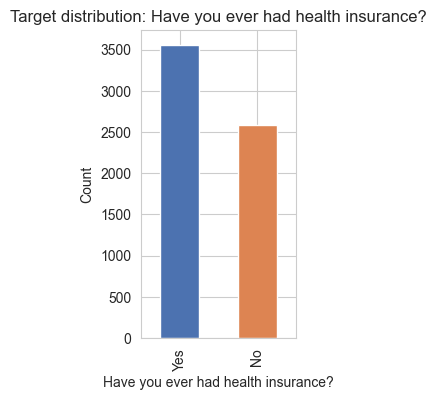

In [51]:
plt.figure(figsize=(2, 4))

# Drop rows with a missing target — we can't train on those
data = data.dropna(subset=[target_col])
print('Rows after dropping missing target:', len(data))

# Target distribution
print(data[target_col].value_counts())
data[target_col].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Target distribution: Have you ever had health insurance?')
plt.ylabel('Count')
plt.show()

In [28]:
# Missing values per feature
data.isna().mean().sort_values(ascending=False).round(3)

How many children do you have, if any?                                              0.101
Monthly Household Income                                                            0.041
When was the last time you visited a hospital for medical treatment? (In Months)    0.024
Did you have health insurance during your last hospital visit?                      0.008
Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?           0.004
Have you ever had a routine check-up with a doctor or healthcare provider?          0.003
Employment Status                                                                   0.003
Age                                                                                 0.002
Gender                                                                              0.002
Marital Status                                                                      0.002
Have you ever had health insurance?                                                 0.000
dtype: flo

In [29]:
# Impute: numeric -> median, categorical -> a 'Not Applicable' / 'Unknown' category
numeric_features = [
    'How many children do you have, if any?',
    'When was the last time you visited a hospital for medical treatment? (In Months)',
]
categorical_features = [c for c in feature_cols if c not in numeric_features]

for col in numeric_features:
    data[col] = data[col].fillna(data[col].median())

for col in categorical_features:
    data[col] = data[col].fillna('Unknown')

data.isna().sum().sum()  # should be 0

np.int64(0)

## 5. Encode categorical features & target

In [30]:
encoders = {}
data_enc = data.copy()

for col in categorical_features:
    le = LabelEncoder()
    data_enc[col] = le.fit_transform(data_enc[col].astype(str))
    encoders[col] = le

target_encoder = LabelEncoder()
data_enc[target_col] = target_encoder.fit_transform(data_enc[target_col].astype(str))
print('Target classes:', list(target_encoder.classes_), '->', list(range(len(target_encoder.classes_))))

data_enc.head()

Target classes: ['No', 'Yes'] -> [0, 1]


,Age,Gender,Marital Status,"How many children do you have, if any?",Employment Status,Monthly Household Income,When was the last time you visited a hospital for medical treatment? (In Months),Did you have health insurance during your last hospital visit?,Have you ever had a routine check-up with a doctor or healthcare provider?,"Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?",Have you ever had health insurance?
0,2,0,1,2.0,1,1,53.0,0,2,0,1
1,0,1,2,0.0,2,5,8.0,0,2,0,0
2,2,0,1,5.0,1,1,6.0,2,0,2,0
3,0,1,2,2.0,1,0,16.0,2,0,0,1
4,2,1,1,7.0,1,1,13.0,2,0,2,1


## 6. Quick correlation check

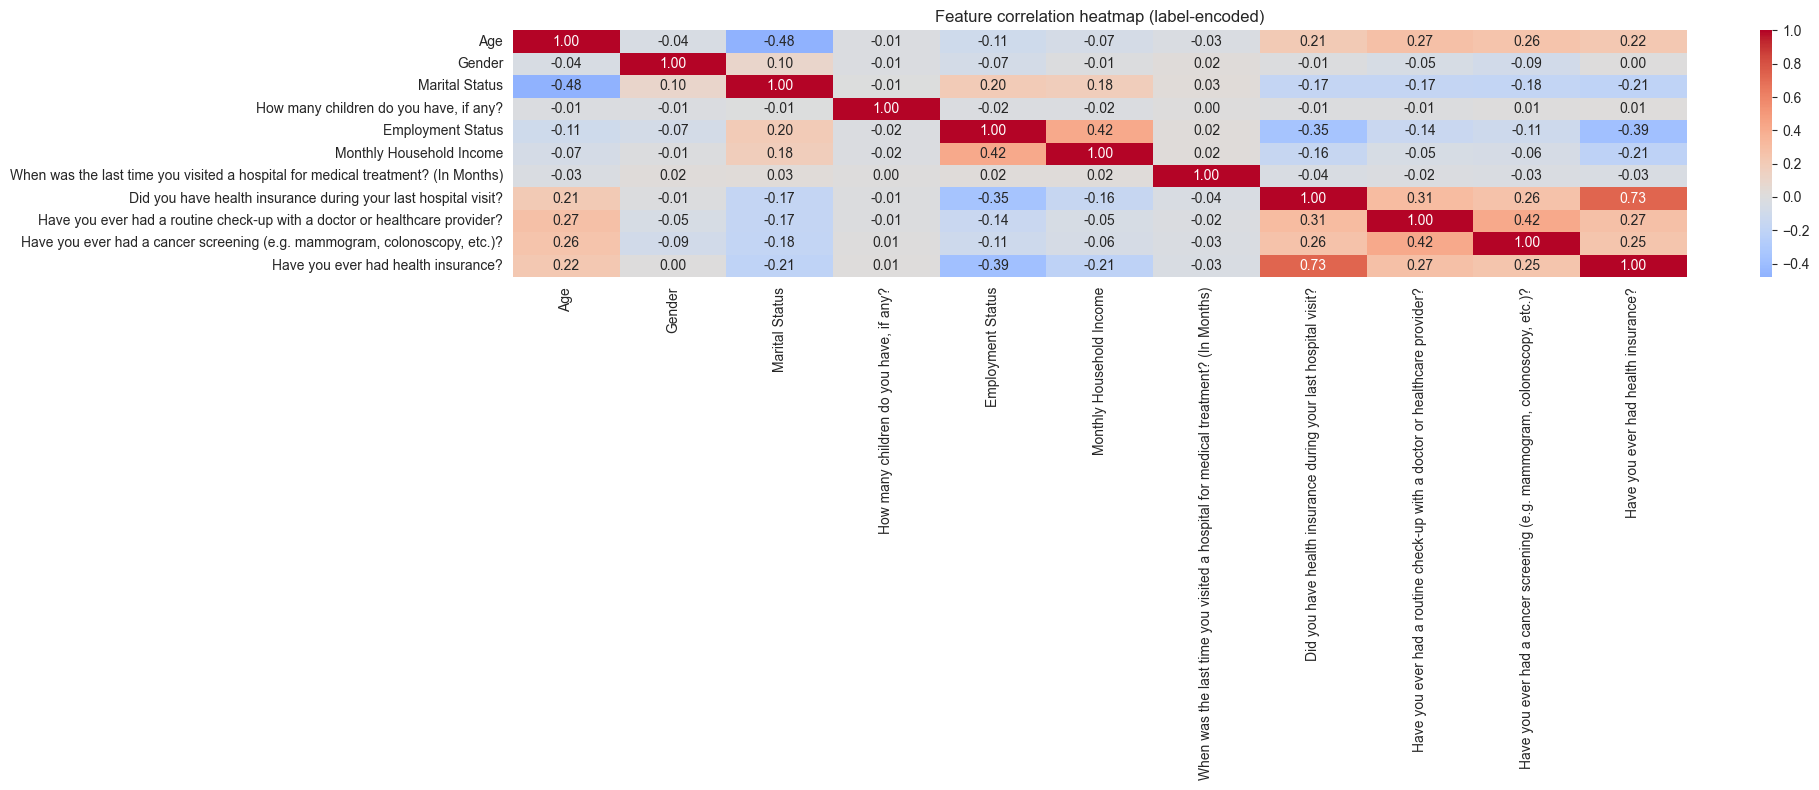

In [60]:
plt.figure(figsize=(20, 8))
sns.heatmap(data_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap (label-encoded)')
plt.tight_layout()
plt.show()

## 7. Train / test split & scaling

In [32]:
X = data_enc[feature_cols]
y = data_enc[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (4911, 10)  Test shape: (1228, 10)


## 8. Train every model

Tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) use the
**unscaled** features since they're scale-invariant. Distance/gradient-based models
(Logistic Regression, KNN, SVM) use the **scaled** features.


In [33]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    'K-Nearest Neighbors': (KNeighborsClassifier(n_neighbors=15), True),
    'Decision Tree': (DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE), False),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE), False),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE), False),
    'XGBoost': (XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               eval_metric='logloss', random_state=RANDOM_STATE), False),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), True),
    'Naive Bayes': (GaussianNB(), False),
}

results = []
fitted_models = {}

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else preds

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs),
    })
    fitted_models[name] = (model, needs_scaling, preds, probs)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.843648,0.933333,0.786517,0.853659,0.912970
1,Gradient Boosting,0.843648,0.926230,0.793539,0.854766,0.910532
2,XGBoost,0.841205,0.920325,0.794944,0.853052,0.909184
3,Logistic Regression,0.840391,0.941781,0.772472,0.848765,0.906620
4,K-Nearest Neighbors,0.838762,0.905363,0.806180,0.852897,0.903029
5,Decision Tree,0.844463,0.945299,0.776685,0.852737,0.898076
6,Naive Bayes,0.700326,0.972527,0.497191,0.657993,0.892992
7,SVM (RBF),0.841205,0.944923,0.771067,0.849188,0.882178


## 9. Compare models visually

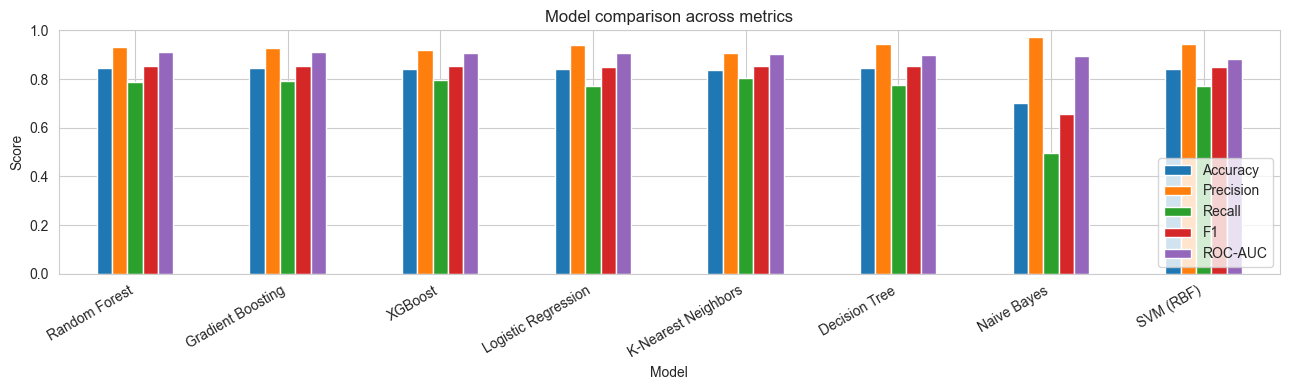

In [34]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics_to_plot]

ax = plot_df.plot(kind='bar', figsize=(13, 4))
plt.title('Model comparison across metrics')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model by ROC-AUC: Random Forest


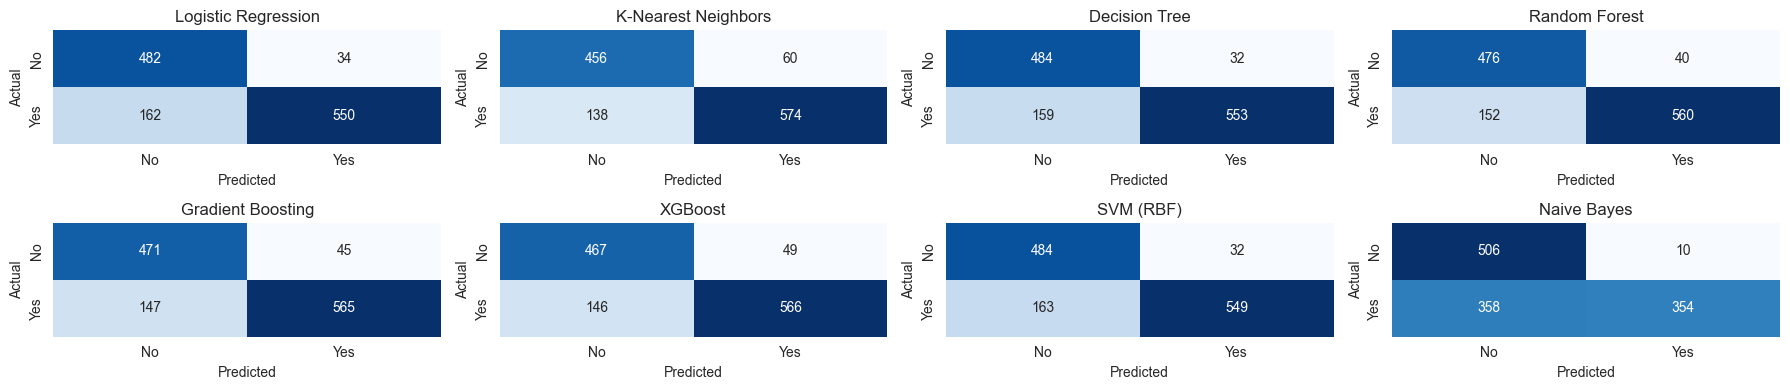

In [35]:
best_model_name = results_df.iloc[0]['Model']
print(f'Best model by ROC-AUC: {best_model_name}')

fig, axes = plt.subplots(2, 4, figsize=(18, 4))
axes = axes.ravel()
for i, name in enumerate(models.keys()):
    _, _, preds, _ = fitted_models[name]
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

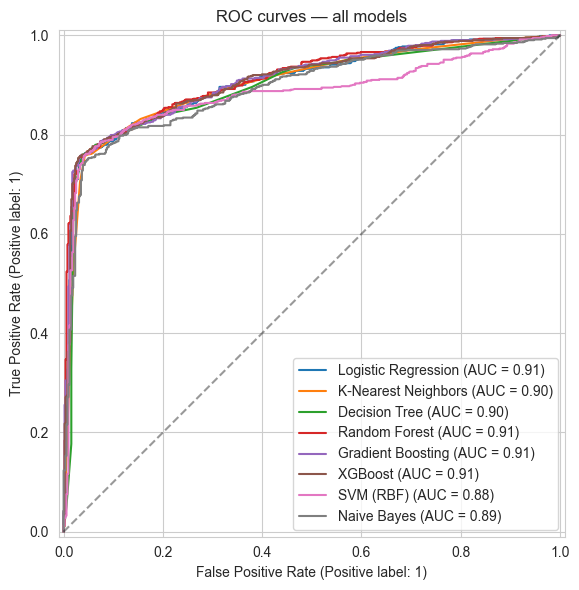

In [43]:
plt.figure(figsize=(13, 6))
for name in models.keys():
    model, needs_scaling, preds, probs = fitted_models[name]
    Xte = X_test_scaled if needs_scaling else X_test
    RocCurveDisplay.from_estimator(model, Xte, y_test, name=name, ax=plt.gca())
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.title('ROC curves — all models')
plt.tight_layout()
plt.show()

## 10. Feature importance (tree-based models)

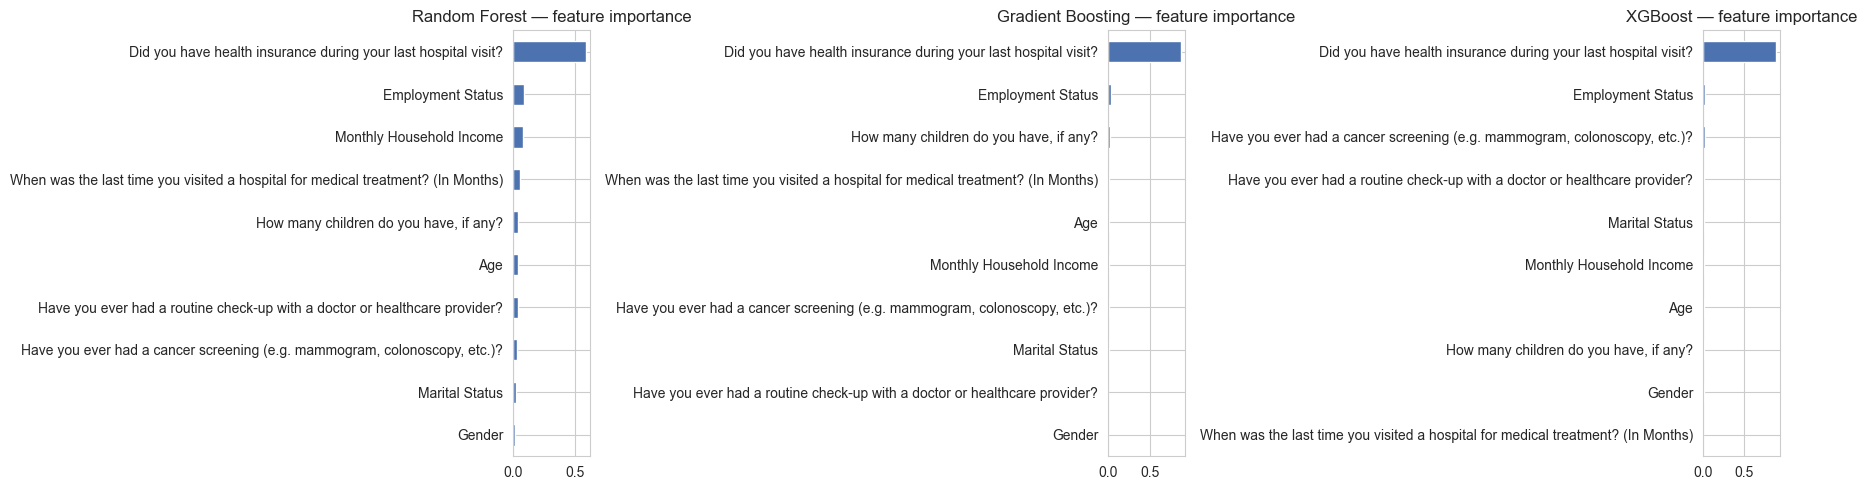

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting', 'XGBoost']):
    model = fitted_models[name][0]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    importances.plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(f'{name} — feature importance')
plt.tight_layout()
plt.show()

## 11. Detailed report for the best model

In [38]:
best_model, needs_scaling, best_preds, best_probs = fitted_models[best_model_name]
print(f'=== {best_model_name} ===\n')
print(classification_report(y_test, best_preds, target_names=target_encoder.classes_))

# 5-fold cross-validation for a more robust estimate
Xcv = X_train_scaled if needs_scaling else X_train
cv_scores = cross_val_score(best_model, Xcv, y_train, cv=5, scoring='roc_auc')
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')

=== Random Forest ===

              precision    recall  f1-score   support

          No       0.76      0.92      0.83       516
         Yes       0.93      0.79      0.85       712

    accuracy                           0.84      1228
   macro avg       0.85      0.85      0.84      1228
weighted avg       0.86      0.84      0.84      1228



5-fold CV ROC-AUC: 0.922 (+/- 0.004)


## 12. Summary

- All 8 classifiers were trained on the same 80/20 stratified split of the cleaned survey data.
- The **results table** and **bar chart** in sections 8–9 rank every model on Accuracy, Precision,
  Recall, F1, and ROC-AUC — use those to pick the model that fits your priorities (e.g. Recall
  matters more if the cost of missing an uninsured respondent is high).
- **Feature importance** plots show which survey questions drive the prediction most for the
  tree-based models — typically prior hospital-visit insurance status, employment, and income
  band are the strongest signals.
- Swap `test_size`, hyperparameters, or add `GridSearchCV`/`RandomizedSearchCV` to tune further.
